<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB43 · Zancudo aprende a andar

**Parte 5 · La física del cuerpo — Lección 8 (y última)**

> En el **NB42** construiste a **Zancudo**, tu propio bípedo, y comprobaste que se sostiene de pie... pero que no sabe hacer nada más. Con un empujón de 200 N se cae, porque no sabe dar un paso.

Hoy se junta **todo**. Vamos a convertir a Zancudo en un **entorno de Gymnasium** (como hiciste con el palo de escoba en el NB25), tomando cada decisión de diseño con lo que has aprendido en esta parte: qué puede **medir** un robot real (NB41), cómo se manda a sus motores (NB40), por qué conviene andar con las rodillas dobladas (NB39)... Y después lo entrenaremos con **PPO** (NB33, NB34), como a Hopper y Walker2d en el NB35, para que aprenda a **andar**.

Es el último notebook de la Parte 5. Si todo va bien, al final habrás hecho, de principio a fin, lo que hace un ingeniero de locomoción: **diseñar un robot, describirlo, simularlo, definir su tarea y entrenarlo**.


## 1 · Las cuatro decisiones de un entorno

Recuerda el NB03 y el NB25: un entorno de RL se define con cuatro cosas. Para un robot de verdad, cada una es una **decisión de ingeniería**, y cada una tiene consecuencias. Estas son las de Zancudo, y por qué.

### Decisión 1 · La observación: solo lo que un robot real podría medir

En el NB41 vimos que una política que confía en información privilegiada se hunde con un poco de ruido. Así que Zancudo verá **18 números**, todos cosas que un robot real **puede** medir (o estimar):

| Números | Qué | De dónde saldrían en un robot real |
|---|---|---|
| 6 | ángulos de cadera, rodilla y tobillo (las dos piernas) | los **codificadores** (NB41) |
| 6 | sus velocidades de giro (× 0,1) | diferencias de los codificadores, suavizadas (NB41) |
| 2 | inclinación del torso y su velocidad de giro (× 0,1) | la **IMU** con su filtro complementario (NB41) |
| 2 | velocidad del torso hacia delante y hacia arriba | **estimada** combinando IMU y patas (un filtro de Kalman, NB41) |
| 2 | **reloj de fase**: seno y coseno de un ángulo que da una vuelta cada 0,8 s | un reloj interno (NB36: la fase de un paso) |

**No** ve su posición x (¿para qué?, NB35) ni la altura exacta del torso. Los "× 0,1" ponen las velocidades en una escala parecida a los ángulos (NB32; además usaremos `VecNormalize`, NB35). La velocidad del torso es la más "tramposa" de la lista: un robot real solo puede **estimarla**, y con error. Lo aceptamos por ahora, sabiendo que en un robot real habría que estimarla.

¿Y el reloj? Es la idea del **generador central de patrones** del NB36: darle a la política un ritmo hecho, para que no tenga que inventarlo. Andar es cíclico, y con un reloj es más fácil aprender "en esta parte del ciclo, levanta la pierna derecha".

### Decisión 2 · La acción: ángulos objetivo, alrededor de una postura agachada

Como los robots reales (NB40), la política **no** da pares, sino **ángulos objetivo** para los motores de posición de Zancudo (con su PD dentro, NB42). Pero no cualquier ángulo: la acción (6 números de −1 a 1) dice **cuánto apartarse** de una **postura base**:

```
   ángulo objetivo  =  postura base  +  amplitud × acción
```

- La **postura base** es "de pie con las rodillas un poco dobladas": cadera +0,3, rodilla −0,6, tobillo +0,3 (los ángulos suman 0 → pie plano, NB36). Rodillas dobladas, como los humanoides del NB39: así puede mantener el centro de masas a altura constante y absorber golpes (NB42, ejercicio E5).
- La **amplitud** (1 rad en caderas y rodillas, 0,6 en tobillos) limita cuánto se puede apartar.

Así, con la acción a cero, Zancudo se queda de pie agachado: la política empieza desde una postura **sensata**, no desde el muñeco de trapo (NB40).

La política decide **50 veces por segundo** (cada 10 pasitos de 0,002 s), como en los robots reales, mientras el PD de los motores corrige en cada pasito (500 veces por segundo).

### Decisión 3 · La recompensa

La misma receta que Hopper y Walker2d (NB35), que ya sabemos que funciona... y que ya sabemos que tiene trampas:

```
   recompensa  =  1 × velocidad hacia delante  +  1 (por seguir vivo)  −  0,01 × suma de acciones²
```

### Decisión 4 · El final

- **Caído** (*terminated*): si la cadera baja de **0,55 m** (estaba a unos 0,83) o el torso se inclina más de **0,8 rad** (46°).
- **Truncado**: a los **1.000 pasos** de decisión, es decir, **20 segundos**.

Con esto, andar a, digamos, 1,5 m/s durante los 20 segundos daría 1.000 × (1 + 1,5) = 2.500 puntos; y fíjate: la recompensa **no tiene techo**, cuanto más rápido, más cobra (lo recordaremos al final). Quedarse de pie quieto, sin caerse, da **1.000**: la trampa de sobrevivir del NB35 está ahí, esperando.


## 2 · El código del entorno

El entorno está en el fichero `zancudo_env.py`, junto a este notebook (como el `palo.py` del NB26). Es una **clase** que hereda de `gym.Env` (NB24, NB25), con sus métodos `reset` y `step`. En vez de copiarlo aquí, vamos a **leerlo** trozo a trozo, directamente del fichero, con el módulo `inspect` de Python, que puede mostrar el código fuente de cualquier función:


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"
import inspect
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

import zancudo_env                          # al importarlo, registra "Zancudo-v0" en Gymnasium
from zancudo_env import Zancudo

Primero, `__init__`, donde se carga el robot y se definen los espacios de observación y de acción (NB25):

In [2]:
print(inspect.getsource(Zancudo.__init__))

    def __init__(self, render_mode=None, peso_avance=1.0, peso_vida=1.0, peso_control=0.01,
                 ruido_obs=0.0, max_pasos=1000):
        self.modelo = mujoco.MjModel.from_xml_path(str(FICHERO))
        self.datos = mujoco.MjData(self.modelo)
        self.submuestreo = 10                       # 10 pasitos de 0,002 s = la política decide 50 veces por segundo
        self.dt = self.modelo.opt.timestep * self.submuestreo
        self.peso_avance, self.peso_vida, self.peso_control = peso_avance, peso_vida, peso_control
        self.ruido_obs = ruido_obs
        self.max_pasos = max_pasos
        self.render_mode = render_mode
        self.renderer = None
        # postura de partida (de pie, un poco agachado) y cuánto puede apartarse de ella cada articulación
        self.postura_base = np.array([0.3, -0.6, 0.3, 0.3, -0.6, 0.3])
        self.amplitud = np.array([1.0, 1.0, 0.6, 1.0, 1.0, 0.6])
        self.action_space = spaces.Box(-1.0, 1.0, shape=(6,), dtype=np.float32)
      

Fíjate en `self.submuestreo = 10` (50 decisiones por segundo), en la **postura base** y la **amplitud** de la decisión 2, y en los espacios: acción de 6 números entre −1 y 1, observación de 18. Ahora, la observación:

In [3]:
print(inspect.getsource(Zancudo._observacion))

    def _observacion(self):
        d = self.datos
        angulos = d.qpos[3:9]                       # codificadores: los 6 ángulos de las articulaciones
        velocidades = d.qvel[3:9]                   # sus velocidades de giro
        inclinacion = d.qpos[2]                     # la inclinación del torso (la daría la IMU con su filtro, NB41)
        giro = d.qvel[2]                            # la velocidad de giro del torso (el giróscopo)
        vel_torso = d.qvel[0:2]                     # velocidad hacia delante y hacia arriba del torso (estimada)
        fase = 2 * np.pi * self.pasos * self.dt / 0.8      # un reloj que da una vuelta cada 0,8 s (NB36)
        obs = np.concatenate([angulos, velocidades * 0.1, [inclinacion, giro * 0.1],
                              vel_torso, [np.sin(fase), np.cos(fase)]])
        if self.ruido_obs > 0:
            obs = obs + self.np_random.normal(0, self.ruido_obs, obs.shape)
        return obs



Exactamente la tabla de la decisión 1. `qpos[3:9]` son los seis ángulos de las articulaciones (las tres primeras posiciones de `qpos` son la raíz: x, z, giro, NB42), `qvel` sus velocidades... y el reloj de fase. También tiene preparado un `ruido_obs` para añadir ruido a las observaciones, que usaremos en la sección 7. Ahora, `reset`:

In [4]:
print(inspect.getsource(Zancudo.reset))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.modelo, self.datos)
        # partimos de la postura base, con un poquito de azar (NB25)
        self.datos.qpos[3:9] = self.postura_base + self.np_random.uniform(-0.05, 0.05, 6)
        self.datos.qpos[1] = -0.8 * (1 - np.cos(0.3))   # bajamos el torso lo que baja al agacharse (NB36), para que los pies toquen el suelo
        self.datos.ctrl[:] = self.postura_base
        mujoco.mj_forward(self.modelo, self.datos)
        self.pasos = 0
        return self._observacion(), {}



Coloca al robot en la postura base con un poco de **azar** (±0,05 rad en cada articulación, para que cada episodio empiece distinto y la política no memorice uno solo: NB25), y lo **baja** lo que baja la cadera al doblar las rodillas, que se calcula con el coseno del NB36: 0,8 × (1 − cos 0,3). Y el corazón, `step`:

In [5]:
print(inspect.getsource(Zancudo.step))

    def step(self, accion):
        accion = np.clip(accion, -1, 1)
        objetivo = self.postura_base + self.amplitud * accion           # la acción = ángulos objetivo (NB40)
        self.datos.ctrl[:] = np.clip(objetivo, self.modelo.actuator_ctrlrange[:, 0], self.modelo.actuator_ctrlrange[:, 1])
        x_antes = self.datos.qpos[0]
        for _ in range(self.submuestreo):
            mujoco.mj_step(self.modelo, self.datos)
        self.pasos += 1
        velocidad = (self.datos.qpos[0] - x_antes) / self.dt
        altura = 0.865 + self.datos.qpos[1]          # altura de la cadera sobre el suelo
        inclinacion = self.datos.qpos[2]
        caido = altura < 0.55 or abs(inclinacion) > 0.8
        recompensa = (self.peso_avance * velocidad + self.peso_vida
                      - self.peso_control * float(np.sum(accion ** 2)))
        truncado = self.pasos >= self.max_pasos
        info = {"x": self.datos.qpos[0], "velocidad": velocidad}
        return self._observacion(), recompe

Paso a paso:

1. Convierte la acción en **ángulos objetivo** y se los da a los motores (`ctrl`), recortados a sus límites.
2. Avanza la física **10 pasitos** con `mj_step`.
3. Calcula la **velocidad** hacia delante (cuánto ha avanzado la x, dividido entre el tiempo, NB16).
4. Comprueba si se ha **caído** (altura de la cadera o inclinación del torso).
5. Calcula la **recompensa** con la receta de la decisión 3.

Todo lo que has aprendido en la Parte 3 de Python (clases, herencia, módulos) y en la Parte 5 de física, en unas 30 líneas.


## 3 · Comprobaciones y referencias

Primero, que el entorno cumple las normas de Gymnasium, con `check_env` (NB25):

In [6]:
from gymnasium.utils.env_checker import check_env

check_env(Zancudo())
print("check_env: todo correcto")

check_env: todo correcto


/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:317: UserWarning: WARN: A Box observation space minimum value is -infinity. This is probably too low.
  logger.warn(
/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:321: UserWarning: WARN: A Box observation space maximum value is infinity. This is probably too high.
  logger.warn(
/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:440: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


Y, como siempre (NB04, NB11, NB35), antes de entrenar medimos las **políticas de referencia**: no hacer nada (acción 0: quedarse en la postura base) y moverse al azar. Una función para jugar episodios, como la del NB35:

In [7]:
zancudo = gym.make("Zancudo-v0")

def jugar_episodios(entorno, politica, n=10):
    retornos, duraciones, distancias = [], [], []
    for semilla in range(n):
        observacion, info = entorno.reset(seed=semilla)
        retorno, pasos = 0.0, 0
        while True:
            observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
            retorno += recompensa
            pasos += 1
            if terminado or truncado:
                break
        retornos.append(retorno)
        duraciones.append(pasos)
        distancias.append(info["x"])
    return np.mean(retornos), np.mean(duraciones), np.mean(distancias)

for nombre, politica in [("quieto", lambda obs: np.zeros(6)), ("azar", lambda obs: zancudo.action_space.sample())]:
    r, d, x = jugar_episodios(zancudo, politica)
    print(f"{nombre:>6}: retorno {r:6.1f} | dura {d:6.1f} pasos ({d * 0.02:.1f} s) | acaba en x = {x:+.2f} m")

quieto: retorno  832.6 | dura  832.8 pasos (16.7 s) | acaba en x = -0.00 m


  azar: retorno   57.1 | dura   55.7 pasos (1.1 s) | acaba en x = +0.05 m


Dos referencias, dos historias:

- **Quieto: 832,6 puntos.** ¿No habíamos dicho que quedarse quieto daba 1.000? Casi: en **8 de los 10** episodios aguanta los 20 segundos de pie (1.000 puntos cada uno), pero en **2** (semillas 0 y 2) se cae de espaldas, a los 228 y a los 100 pasos. Es el pequeño azar de la postura de partida (±0,05 rad en cada articulación, sección 2): a veces lo deja con el centro de masas un poco por detrás de los pies y, sin nadie que corrija, se va al suelo (NB38). Incluso "no hacer nada" necesita algo de equilibrio.
- **Azar: 57,1 puntos.** Agitando las piernas al azar se cae en **algo más de 1 segundo** (55,7 pasos). Un punto por paso de vida, y poco más.

Así que el listón está claro: cualquier agente que saque menos de ~830 lo hace **peor que quedarse quieto**, y para pasar de 1.000 tiene que **avanzar** de verdad.


## 4 · Un entrenamiento corto, en directo

Antes del entrenamiento largo, veamos que todo funciona con uno corto, aquí mismo: PPO con los ajustes por defecto y `VecNormalize` (NB35), durante 106.496 pasos (13 lotes de 8.192, NB34):

In [8]:
import time
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
import torch
torch.set_num_threads(2)

inicio = time.time()
entornos = VecNormalize(make_vec_env("Zancudo-v0", n_envs=4, seed=0))
agente_corto = PPO("MlpPolicy", entornos, seed=0)
agente_corto.learn(total_timesteps=106_496)
print(f"entrenado en {time.time() - inicio:.0f} s")

entrenado en 1034 s


In [9]:
entornos.training = False
politica_corta = lambda obs: agente_corto.predict(entornos.normalize_obs(obs), deterministic=True)[0]
r, d, x = jugar_episodios(zancudo, politica_corta)
print(f"tras 106.496 pasos: retorno {r:6.1f} | dura {d:6.1f} pasos ({d * 0.02:.1f} s) | acaba en x = {x:+.2f} m")

tras 106.496 pasos: retorno  739.8 | dura  819.6 pasos (16.4 s) | acaba en x = -1.45 m


Tras 106.496 pasos (unos 17 minutos en la Pi, que estaba ocupada con otros entrenamientos a la vez): **739,8 puntos**, aguanta de media **16,4 segundos**... y acaba en **x = −1,45 m**. ¡Ha ido **hacia atrás**!

Es exactamente lo que se ve al principio de todo entrenamiento de locomoción: lo primero que aprende es a **no caerse** (cada paso de vida es un punto seguro), y todavía no sabe avanzar. De hecho, saca **menos que quedarse quieto** (832,6): aún no ha llegado ni al nivel de "no hacer nada". Es la **trampa de sobrevivir** en directo.

No te preocupes: con más pasos sale de ahí. Lo verás en la gráfica de la sección siguiente (el primer punto de la curva `defecto`, a esos mismos 106.496 pasos, también está por debajo de los 1.000 y también acaba un poco por detrás del inicio). Las cifras no coinciden exactamente con las de aquí: entrenar en otro momento, con otra carga en la máquina, cambia un poco los resultados aunque la semilla sea la misma (NB34).


## 5 · El entrenamiento largo

Para que ande de verdad hacen falta más pasos. Igual que en el NB35, lo entrené **antes**, con un script, `entrenar_zancudo.py` (está junto a este notebook), con cuatro entrenamientos a la vez en la Pi, uno por núcleo:

- `defecto`, semilla 0: los ajustes por defecto de SB3.
- `afinado`, semillas 0 y 1: los ajustes afinados del NB35 (lotes pequeños, redes de 256, campana inicial estrecha). Dos semillas, para ver cuánto depende del azar (NB34, NB35).
- `afinado` con **ruido** de 0,02 en las observaciones (sección 7).

El script es el del NB35 con dos mejoras: examina en Zancudo-v0 y, aprendiendo la lección del NB35, guarda **también el mejor** agente (no solo el último). Sus registros, tramo a tramo (pasos, nota media de 5 episodios, su desviación y la distancia media recorrida en los 20 s):


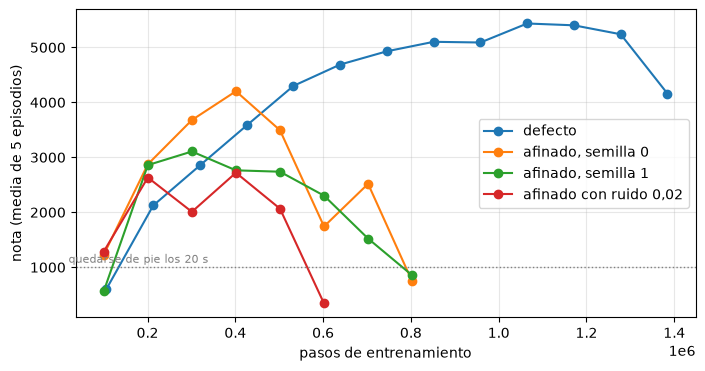

In [10]:
# (pasos, nota media de 5 episodios, desviación, distancia media en m) de cada tramo
defecto = [(106_496, 605.6, 372.9, -0.49), (212_992, 2123.3, 69.3, 22.81), (319_488, 2853.8, 34.7, 37.53),
           (425_984, 3580.6, 87.3, 52.15), (532_480, 4300.0, 181.3, 66.9), (638_976, 4688.5, 71.9, 74.38),
           (745_472, 4929.8, 29.1, 79.21), (851_968, 5102.0, 61.0, 82.67), (958_464, 5089.4, 379.0, 83.11),
           (1_064_960, 5435.2, 29.8, 89.37), (1_171_456, 5402.1, 502.3, 89.57), (1_277_952, 5239.3, 1167.6, 87.33),
           (1_384_448, 4160.1, 1672.6, 69.34)]
afinado_s0 = [(100_352, 1230.2, 549.4, 12.55), (200_704, 2873.4, 685.5, 39.64), (301_056, 3678.3, 53.9, 54.05),
              (401_408, 4202.5, 77.1, 64.49), (501_760, 3493.0, 777.0, 54.25), (602_112, 1741.7, 1564.7, 27.13),
              (702_464, 2517.4, 2166.7, 40.19), (802_816, 744.2, 516.6, 11.18)]
afinado_s1 = [(100_352, 566.2, 309.2, 5.43), (200_704, 2858.6, 45.5, 37.41), (301_056, 3106.0, 38.8, 42.43),
              (401_408, 2763.0, 633.5, 38.34), (501_760, 2738.2, 672.1, 37.29), (602_112, 2302.1, 1133.9, 30.3),
              (702_464, 1521.7, 1273.6, 20.42), (802_816, 853.4, 668.9, 11.26)]
afinado_ruido = [(100_352, 1286.0, 680.9, 11.73), (200_704, 2632.4, 643.5, 34.99), (301_056, 2008.2, 758.0, 27.28),
                 (401_408, 2719.6, 910.6, 37.83), (501_760, 2065.3, 958.9, 29.74), (602_112, 339.9, 419.4, 4.55)]

plt.figure(figsize=(8, 4))
for nombre, registro in [("defecto", defecto), ("afinado, semilla 0", afinado_s0),
                         ("afinado, semilla 1", afinado_s1), ("afinado con ruido 0,02", afinado_ruido)]:
    plt.plot([p for p, *resto in registro], [nota for p, nota, *resto in registro], marker="o", label=nombre)
plt.axhline(1000, color="gray", ls=":", lw=1)
plt.text(20_000, 1080, "quedarse de pie los 20 s", color="gray", fontsize=8)
plt.xlabel("pasos de entrenamiento")
plt.ylabel("nota (media de 5 episodios)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


(Los `*resto` desempaquetan "lo que sobre" de cada tupla, NB23: solo queremos los pasos y la nota.)

Las cuatro curvas cuentan dos historias muy distintas.

**`defecto`: aprende, y mucho.** A los 200.000 pasos ya supera la trampa de sobrevivir (la línea de 1.000 puntos: quedarse de pie los 20 segundos) y sigue subiendo, tramo a tramo, hasta su mejor examen: **5.435 puntos** al millón de pasos, recorriendo **89 metros** en los 20 segundos. ¡Más de **4 m/s**! Después empieza a oscilar (la desviación se dispara a ±1.672 en el último tramo): había llegado a su techo y empezaba a "estropearse".

**Los tres `afinado`: suben deprisa... y se derrumban.** Los tres aprenden **antes** que `defecto` (a los 200.000 pasos ya rondan los 2.600-2.900 puntos, y `afinado` semilla 0 llega a **4.202** a los 400.000). Pero después, **los tres** se vienen abajo, hasta notas por debajo de lo que sacaría quedándose quieto (744, 853, 340). Y no es mala suerte de una semilla: le pasa a las dos semillas y a la versión con ruido.

Es un fenómeno conocido y temido del RL: el **colapso de la política**. La política mejora, se vuelve más atrevida, y en algún momento una actualización la empuja a una zona en la que empieza a caerse; al caerse, recoge experiencia mala, y las siguientes actualizaciones la hunden más. Los ajustes `afinado` (lotes pequeños de 512 pasos por copia, y una tasa de aprendizaje que no baja nunca) hacen actualizaciones frecuentes y ruidosas (NB33, NB35): son **rápidos** pero **frágiles**. Con Hopper en el NB35 ya vimos que oscilaban más; aquí, con un robot más difícil, directamente se derrumban.

Tres lecciones de profesional, todas a la vez:

1. **Guarda el mejor, no el último** (NB35). Gracias a que el script guarda también el mejor examen, de cada entrenamiento derrumbado tenemos su mejor versión. Si solo hubiéramos guardado el último, los tres `afinado` serían basura.
2. **Lo rápido no es lo mejor.** `afinado` aprendió antes, pero `defecto`, más lento y más estable, llegó más lejos.
3. **Vigila los entrenamientos.** Paré los cuatro cuando quedó claro que ya no iban a mejorar. Más pasos no siempre es mejor: es tiempo de máquina (y en la nube, dinero) tirado.

Nos quedamos con el mejor de `defecto` como **campeón**.


## 6 · El examen del campeón

Cargamos el **mejor** agente (con sus estadísticas de `VecNormalize`: ¡las dos cosas!, NB35) y lo examinamos con 10 episodios:

In [11]:
from pathlib import Path
MODELOS = Path("modelos")

def cargar(nombre):
    agente = PPO.load(MODELOS / nombre)
    normalizador = VecNormalize.load(MODELOS / f"{nombre}_norm.pkl", make_vec_env("Zancudo-v0", n_envs=1))
    normalizador.training = False
    return agente, normalizador

agente, normalizador = cargar("zancudo_defecto_mejor")
politica = lambda obs: agente.predict(normalizador.normalize_obs(obs), deterministic=True)[0]
r, d, x = jugar_episodios(zancudo, politica)
print(f"Zancudo entrenado: retorno {r:6.1f} | dura {d:6.1f} pasos ({d * 0.02:.1f} s) | recorre {x:5.2f} m (≈ {x / (d * 0.02):.2f} m/s)")

Zancudo entrenado: retorno 5452.9 | dura 1000.0 pasos (20.0 s) | recorre 89.72 m (≈ 4.49 m/s)


**5.453 puntos** de media en 10 episodios, y **todos** duran los 1.000 pasos: ni una caída en 200 segundos de examen. Recorre **89,7 metros** en 20 segundos: **4,49 m/s**, unos **16 km/h**. Un robot de 23,6 kg que diseñaste tú, en un simulador de física real, con una política que ha aprendido sola en una Raspberry Pi.

Y ahora, a verlo. Un GIF de los primeros 6 segundos (NB34, NB35), con la cámara `lado` que le pusimos en el NB42:


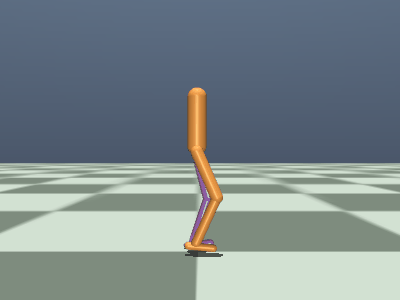

In [12]:
import imageio
from IPython.display import Image

def grabar(politica, ruta, pasos=300, cada=2, semilla=0):
    camara = Zancudo(render_mode="rgb_array")
    observacion, info = camara.reset(seed=semilla)
    fotos = []
    for paso in range(pasos):
        observacion, recompensa, terminado, truncado, info = camara.step(politica(observacion))
        if paso % cada == 0:
            fotos.append(camara.render())
        if terminado or truncado:
            break
    camara.close()
    imageio.mimsave(ruta, fotos, fps=round(1 / (0.02 * cada)), loop=0)
    return len(fotos)

os.makedirs("assets", exist_ok=True)
grabar(politica, "assets/nb43_zancudo.gif")
Image(filename="assets/nb43_zancudo.gif")

Fíjate bien en **cómo** se mueve, porque será el tema de la Parte 6:

- Parte agachado, se **inclina hacia delante** (se deja caer, como en el NB39) y arranca con **zancadas enormes**: la pierna que avanza se lanza muy por delante y muy alta.
- En muchos fotogramas **ningún pie toca el suelo**: no anda, **corre a saltos**.
- El torso va casi recto, con una ligera inclinación hacia delante, y **no se cae nunca**.

Es eficaz (89 metros en 20 segundos), pero no es la forma de andar que tenías en la cabeza cuando diseñaste a Zancudo. Volveremos a ello en la sección 8.


## 7 · ¿Es robusto?

Un robot que anda en la simulación perfecta no es un robot que anda en el mundo. Hagámosle a nuestro campeón dos pruebas de la Parte 5.

### Prueba 1: empujones

Como en el NB42: mientras anda, a los 4 segundos, un empujón en el torso de 0,05 s, hacia delante o hacia atrás. Una función que juega un episodio con empujón y dice si ha llegado al final sin caerse:


In [13]:
import mujoco

def anda_con_empujon(politica, fuerza, semilla=0, n_pasos=500):
    entorno = Zancudo()
    torso = mujoco.mj_name2id(entorno.modelo, mujoco.mjtObj.mjOBJ_BODY, "torso")
    observacion, info = entorno.reset(seed=semilla)
    for paso in range(n_pasos):                         # 10 segundos
        if 200 <= paso < 203:                           # a los 4 s, durante 3 decisiones (0,06 s)
            entorno.datos.xfrc_applied[torso, 0] = fuerza
        else:
            entorno.datos.xfrc_applied[torso, 0] = 0
        observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
        if terminado:
            return False
    return True

In [14]:
for fuerza in [-300, -200, 200, 300, 400]:
    aguanta = [anda_con_empujon(politica, fuerza, semilla) for semilla in range(5)]
    print(f"empujón de {fuerza:+4d} N: aguanta {sum(aguanta)} de 5")

empujón de -300 N: aguanta 4 de 5


empujón de -200 N: aguanta 5 de 5


empujón de +200 N: aguanta 5 de 5


empujón de +300 N: aguanta 3 de 5


empujón de +400 N: aguanta 3 de 5


Recuerda el NB42: Zancudo **quieto** se caía con un empujón de 200 N durante 0,05 s. Ahora, **andando**, aguanta empujones de **200 N** (durante 0,06 s) en los 5 intentos, hacia delante y hacia atrás, y de **300 N** en 3 de cada 5. ¿Por qué? Porque ahora **da pasos**: cuando lo empujan, su punto de captura (NB39) se desplaza, y la política pone el pie más allá. Nadie le enseñó qué es un punto de captura: lo ha descubierto a base de caerse durante el entrenamiento (cada paso que da ya es, en el fondo, una caída frenada a tiempo). Con 300 y 400 N ya falla a veces: no es invencible.


### Prueba 2: ruido en los sensores

La prueba del NB41: ¿qué le pasa si sus observaciones tienen ruido? Y aquí tenemos un experimento preparado: el cuarto entrenamiento, que se hizo **con** ruido de 0,02 en las observaciones. Comparemos los dos agentes, el entrenado sin ruido y el entrenado con ruido, examinados con distintos niveles de ruido (el entorno lo añade solo, con `ruido_obs`):


In [15]:
agente_r, normalizador_r = cargar("zancudo_ruido_mejor")
politica_r = lambda obs: agente_r.predict(normalizador_r.normalize_obs(obs), deterministic=True)[0]

for ruido in [0.0, 0.02, 0.05]:
    entorno_ruidoso = gym.make("Zancudo-v0", ruido_obs=ruido)
    r1, d1, x1 = jugar_episodios(entorno_ruidoso, politica)
    r2, d2, x2 = jugar_episodios(entorno_ruidoso, politica_r)
    print(f"ruido {ruido:.2f}:  entrenado SIN ruido {r1:6.1f} ({x1:5.1f} m)  |  entrenado CON ruido {r2:6.1f} ({x2:5.1f} m)")

ruido 0.00:  entrenado SIN ruido 5452.9 ( 89.7 m)  |  entrenado CON ruido 2745.1 ( 38.3 m)


ruido 0.02:  entrenado SIN ruido 5107.5 ( 83.9 m)  |  entrenado CON ruido 2680.0 ( 37.4 m)


ruido 0.05:  entrenado SIN ruido 5299.5 ( 86.7 m)  |  entrenado CON ruido 2546.0 ( 34.9 m)


¡Sorpresa! Ninguno de los dos se hunde. El campeón, entrenado **sin** ruido, saca 5.453 sin ruido, 5.108 con ruido de 0,02 y 5.300 con 0,05: diferencias del tamaño del azar entre episodios (fíjate en que con más ruido saca *más* que con menos). El entrenado **con** ruido, igual: 2.745, 2.680 y 2.546, apenas cambia.

(¿Y por qué el entrenado con ruido saca la mitad de nota? No es por el ruido: es un agente `afinado`, de los que se derrumbaron en la sección 5, y su mejor examen en el entrenamiento ya rondaba los 2.700. Comparar dos agentes entrenados con ajustes distintos no dice nada sobre el ruido; lo que sí dice algo es cómo cambia **cada uno** al subir el ruido. Y la respuesta es: casi nada.)

Esto contradice lo que vimos con Hopper en el NB41, donde un ruido de 0,05 hundía su nota de 3.559 a unos 800. ¿Qué es diferente? La explicación más probable está en las **decisiones de diseño** de la sección 1:

- La política de Hopper daba **pares** directamente: un poco de ruido en la observación se convierte en un tirón de par **inmediato**.
- La de Zancudo da **ángulos objetivo**, y los persigue un **PD** (NB40). El PD actúa como un **filtro**: un objetivo que tiembla un poco produce un movimiento suave, porque las articulaciones tienen inercia y el amortiguador frena los cambios bruscos.
- Además, Zancudo parte de una postura **estable** (rodillas dobladas) y su observación tiene números **bien escalados**.

Así que el experimento no ha demostrado que "entrenar con ruido sirve" (aquí no hacía falta), sino algo igual de valioso: **cómo diseñas el entorno decide lo frágil que será la política**. Y una lección de científico: cuando un experimento no sale como esperabas, **no lo escondas**; pregúntate por qué. Aquí, la respuesta nos ha enseñado algo nuevo sobre el diseño de las acciones.


## 8 · Lo que falta para andar "bonito"

Zancudo **se mueve** muy bien: es rápido, aguanta empujones... Pero si lo comparas con cómo anda una persona (o un robot humanoide de verdad), le falta mucho:

- **Corre en vez de andar.** Pasa buena parte del tiempo con los dos pies en el aire. Nadie le dijo "anda"; le dijimos "avanza lo más deprisa que puedas".
- **Va demasiado rápido.** Casi 4,5 m/s, unos 16 km/h. Nadie le pidió una velocidad concreta: cuanto más rápido, más cobra (la recompensa no tiene techo).
- **Da patadas.** Levanta los pies muchísimo más de lo necesario. Nada en la recompensa lo castiga.
- **Puede ir a tirones.** Nada en la recompensa le impide cambiar bruscamente sus acciones de una decisión a la siguiente: en un robot real, eso son golpes en los motores (NB40). Lo mediremos en el NB44.

Todo esto tiene la misma causa: la recompensa dice **qué** (avanzar sin caerse), no **cómo**. Es la lección del NB04 y del NB35 otra vez, y es el tema del primer notebook de la Parte 6: **moldear la recompensa**, para pedirle que **ande**, a la **velocidad que queramos**, sin patadas y con **suavidad**.


## 9 · Resumen de la lección (y de la Parte 5)

1. Un entorno de robot son **cuatro decisiones de ingeniería**: observación, acción, recompensa y final.
2. **Observación** de Zancudo (18): codificadores, velocidades, IMU, velocidad del torso estimada y un **reloj de fase** (CPG, NB36). Nada de x ni de altura exacta.
3. **Acción**: ángulos objetivo = **postura base agachada** + amplitud × acción, a **50 Hz**, con el PD de los motores a 500 Hz (NB40, NB42). Acción cero = de pie.
4. **Recompensa**: avance + vida − control (NB35). **Final**: cadera < 0,55 m o torso > 0,8 rad; 1.000 pasos (20 s).
5. El código, en `zancudo_env.py`: una clase de Gymnasium (leída con `inspect`), que pasa `check_env`.
6. Entrenamiento (4 a la vez en la Pi): `defecto` sube hasta **5.435** (89 m en 20 s); los tres `afinado` aprenden antes y se **derrumban** (colapso de la política). **Guarda el mejor**, no el último. El campeón: 5.453 puntos, 0 caídas en 10 episodios, **4,49 m/s**.
7. Robustez: andando aguanta empujones de 200 N (quieto caía con 200), porque **da pasos** (punto de captura aprendido). El **ruido** apenas le afecta, entrenado con o sin él: acción = ángulos objetivo + PD filtra el ruido (al revés que Hopper, NB41). **El diseño del entorno decide la fragilidad.**
8. La Parte 5 en una frase: con **ángulos** (NB36), **fuerzas y pares** (NB37), el **centro de masas** (NB38), el **punto de captura** (NB39), **motores y PD** (NB40), **sensores** (NB41) y **MJCF** (NB42), has diseñado, construido y entrenado un robot que anda.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Postura base** | La postura de referencia alrededor de la cual la política mueve las articulaciones. |
| **Reloj de fase** | Seno y coseno de un ángulo que gira a ritmo fijo, dado como observación. |
| **Submuestreo** (*frame skip*) | Cuántos pasitos de física por cada decisión de la política. |
| **`inspect.getsource`** | Muestra el código fuente de una función o clase. |


## 10 · Ejercicios

**E1.** Calcula a mano la recompensa máxima por paso si Zancudo anda a 1 m/s sin usar los motores (acción 0), y si corre a 4 m/s con todas las acciones a ±1. ¿Cuánto suma cada caso en 1.000 pasos?

**E2.** En `zancudo_env.py`, el reloj de fase da una vuelta cada 0,8 s. ¿Cuántos pasos de decisión son? Y si el robot da un paso con cada pierna en cada vuelta, ¿cuántos pasos por segundo da?

**E3.** Examina el mejor agente `afinado` (`cargar("zancudo_afinado_mejor")`) con `jugar_episodios`. ¿Cómo se compara con el campeón?

**E4.** Graba un GIF del agente entrenado con ruido (`politica_r`) y compáralo con el del campeón. ¿Anda distinto?

**E5.** **Reto.** Crea un Zancudo **sin** reloj de fase: copia `zancudo_env.py` en `zancudo_sin_reloj.py`, quita el seno y el coseno de la observación (y cambia la `shape` del espacio de observación a 16), y entrénalo 300.000 pasos con `defecto`. ¿Aprende más despacio que con reloj? (Compáralo con el registro de `defecto` en la sección 5.)


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con este notebook se cierra la **Parte 5 · La física del cuerpo**. Lo siguiente es la **Parte 6 · Bípedos de verdad**: aprenderemos a **moldear la recompensa** para que Zancudo ande de forma natural, a hacerlo **robusto** con aleatorización (empujones, masas, ruido y retrasos durante el entrenamiento), a que **obedezca órdenes** (andar a la velocidad que le pidas), y daremos el salto a los **humanoides en 3D**, entrenados con miles de robots a la vez en una GPU de **Colab** con MuJoCo Playground.
